In [1]:
import ctypes as ct
import MDAnalysis as mda
import MDA_unwrap_PBC as unwrap
from scipy.fft import fft, ifft, dct, idct
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
class t_rotBond(ct.Structure):
    '''datatype describing a rotatable bonds and its satellites'''
    _fields_ = (("bondAtomIndices", ct.c_int32*2),
                ("satAtomIndices", ct.c_int32*8),
                ("nSat", ct.c_int32))

class t_rotBondSet(ct.Structure):
    '''datatype describing a list of rotatable bonds (e.g., for a single residue)'''
    _fields_ = (("rotBonds", ct.POINTER(t_rotBond)),
                ("nRotBonds", ct.c_int32))

class t_rotBondSets(ct.Structure):
    '''datatype describing a list of rotatable bond sets (e.g., for each residue in a selection)'''
    _fields_ = (("rotBondSets", ct.POINTER(t_rotBondSet)),
                ("nRotBondSets", ct.c_int32))

In [3]:
#load the shared library with C routines
clib = ct.cdll.LoadLibrary("rotBond.so")

In [4]:
#define argument types of function 'getRotBonds' in imported library 'clib'
clib.getRotBonds.argtypes = [
    #sets of rotatable bonds for each residue
    ct.POINTER(t_rotBondSets),
    #number of residues
    ct.c_int32,
    #list of aatom indices for dihedrals
    np.ctypeslib.ndpointer(dtype=np.int32, ndim=2, flags='C_CONTIGUOUS'),
    #number of dihedrals
    ct.c_int32,
    #pair of atom indices indicating the first and last atom index of each residue
    np.ctypeslib.ndpointer(dtype=np.int32, ndim=2, flags='C_CONTIGUOUS')
]
#define return type of function 'getRotBonds' in imported library 'clib'
clib.getRotBonds.restype = ct.c_int32

In [5]:
def inertiaTensor(sel,atMassLists,pos):
    '''compute inertia tensor for each residue in selection'''
    nRes = sel.residues.n_residues
    I = np.zeros((nRes,3,3))
    r = 0
    for res in sel.residues:
        masses = (atMassLists[r])[:,0]
        crd = (pos[r])
        I[r,0,0] = np.sum(masses * (crd[:,1]**2 + crd[:,2]**2))
        I[r,1,1] = np.sum(masses * (crd[:,0]**2 + crd[:,2]**2))
        I[r,2,2] = np.sum(masses * (crd[:,0]**2 + crd[:,1]**2))
        I[r,0,1] = -np.sum(masses * crd[:,0] * crd[:,1])
        I[r,0,2] = -np.sum(masses * crd[:,0] * crd[:,2])
        I[r,1,2] = -np.sum(masses * crd[:,1] * crd[:,2])
        I[r,1,0] = I[r,0,1]
        I[r,2,0] = I[r,0,2]
        I[r,2,1] = I[r,1,2]
        r += 1
    return I

def angMomLabFrame(sel,atMassLists,pos,vel):
    '''compute angular momentum for each residue in selection'''
    #Note: atMassLists is a list of numpy arrays
    #      => atMassLists itself is not a numpy array
    #Note: pos and vel are lists of numpy arrays
    #      => pos and vel themselves are not numpy arrays
    #Note: center of mass coordinates are expected to have been substracted from pos
    #Note: center of mass velocities are expected to have been substracted from vel
    nRes = sel.residues.n_residues
    L = np.zeros((nRes,3))
    r = 0
    for res in sel.residues:
        L[r] += np.sum(atMassLists[r] * np.cross(pos[r],vel[r]), axis = 0)
        r += 1
    return L

def rotAxes(I):
    '''compute principal axes of rotation for a given inertia tensor'''
    evals,evecs = np.linalg.eig(I)
    #sort eigenvalues and eigenvectors
    idx = evals.argsort()[::-1]   
    evals = evals[idx]
    evecs = evecs[:,idx]
    return evals, evecs

def angMomMolFrame(L,evecs):
    '''project moment of inertia onto principal axes of rotation (given by evecs)'''
    return np.dot(evecs.T,L)

def angMomMolFrameInv(omegaMol,evecs):
    '''project rotation in principal axes of rotation back into lab frame'''
    return np.dot(evecs,omegaMol)

def angMomInfo(sel,atMassLists,pos,vel):
    nRes = sel.residues.n_residues
    I = inertiaTensor(sel,atMassLists,pos)
    L = angMomLabFrame(sel,atMassLists,pos,vel)
    Lmol = np.zeros((nRes,3))
    inertia = np.zeros((nRes,3))
    r = 0
    for res in sel.residues:
        evals,evecs = rotAxes(I[r])
        #rotate angular momentum to molecular frame
        Lmol[r] = angMomMolFrame(L[r],evecs)
        #moments of inertia in molecular frame
        inertia[r] = evals
        omegaMol = Lmol[r] / evals
        omegaLab = angMomMolFrameInv(omegaMol,evecs)
        #subtract rigid body rotation from velocities
        vel[r] -= np.cross(omegaLab,pos[r])
        if np.any(evals <= 0.0):
            print("Error: non-positive eigenvalue in inertia tensor")
            print("Eigenvalues: ",evals)
        if np.any(isinstance(evals,complex)):
            print("Error: complex eigenvalue in inertia tensor")
            print("Eigenvalues: ",evals)
        r += 1
    return Lmol, inertia

def getRotBonds(sel):
    dihed = sel.intra_dihedrals.indices
    resAtomRangeList = np.zeros((len(sel.residues),2), dtype = np.int32)
    i = 0
    for res in sel.residues:
        resAtomRangeList[i][0] = np.amin(res.atoms.indices)
        resAtomRangeList[i][1] = np.amax(res.atoms.indices)
        i += 1
    rotBondSets = t_rotBondSets()
    error = clib.getRotBonds(
        ct.pointer(rotBondSets),
        ct.c_int(len(sel.residues)),
        dihed,
        ct.c_int(len(dihed)),
        resAtomRangeList
    )
    if error != 0:
        print(f'ERROR reported by \'getRotBonds\' function\n')
    return rotBondSets 

class vdos:
    def __init__(self,sel,nCorr):
        self.sel = sel
        self.nCorr = nCorr
        self.nRes = sel.residues.n_residues
        #Note: this is a list of numpy arrays
        #      => atMassLists itself is not a numpy array
        self.atMassLists = []
        for res in self.sel.residues:
            #Note: np.newaxis is used to make the array 2D
            self.atMassLists.append(res.atoms.masses[:,np.newaxis])
        self.resMassList = sel.residues.masses
        self.COMposBuffer = np.zeros((nCorr, self.nRes, 3))
        self.COMvelBuffer = np.zeros((nCorr, self.nRes, 3))
        self.angMomBuffer = np.zeros((nCorr, self.nRes, 3))
        self.inertiaBuffer = np.zeros((nCorr, self.nRes, 3))
        self.tau = np.zeros(nCorr, dtype = float)
        self.wavenumber = np.zeros(nCorr, dtype = float)
        self.trCorr = np.zeros((nCorr, sel.n_residues), dtype = float)
        self.trVDoS = np.zeros((nCorr, sel.n_residues), dtype = float)
        self.rotCorr = np.zeros((nCorr, sel.n_residues), dtype = float)
        self.rotVDoS = np.zeros((nCorr, sel.n_residues), dtype = float)
        self.corrCnt = np.zeros(sel.n_residues, dtype = int)
        self.normalized = 0

    def processStep(self,tStep,time):
        idx = tStep % self.nCorr
        if tStep < self.nCorr:
            self.tau[tStep] = time
        pos = []
        vel = []
        r = 0
        for res in self.sel.residues:
            pos.append(res.atoms.positions)
            vel.append(res.atoms.velocities)
            #self.COMposBuffer[idx,r] = res.atoms.center_of_mass() #too slow
            masses = self.atMassLists[r]
            self.COMposBuffer[idx,r] = np.sum(masses * pos[-1] , axis = 0) / self.resMassList[r]
            self.COMvelBuffer[idx,r] = np.sum(masses * vel[-1], axis = 0) / self.resMassList[r]
            r += 1
        r = 0
        for res in self.sel.residues:
            pos[r] = pos[r] - self.COMposBuffer[idx,r]
            vel[r] = vel[r] - self.COMvelBuffer[idx,r]
            r += 1
        self.angMomBuffer[idx], self.inertiaBuffer[idx] = angMomInfo(self.sel,self.atMassLists,pos,vel)
        if tStep >= self.nCorr - 1:
            self.calcCorr(tStep+1)
            
    def calcCorr(self,idx):
        for i in range(self.nCorr):
            j = idx % self.nCorr
            k = (j + i) % self.nCorr
            self.trCorr[i] += np.sum(self.COMvelBuffer[j] * self.COMvelBuffer[k], axis = 1)
            self.rotCorr[i] += np.sum(self.angMomBuffer[j] * self.angMomBuffer[k] / np.sqrt(self.inertiaBuffer[j] * self.inertiaBuffer[k]), axis = 1).real
        self.corrCnt += 1

    def normalize(self):
        if self.normalized == 0:
            for i in range(self.nRes):
                self.trCorr[:,i] *= self.resMassList[i] / self.corrCnt[i]
                self.rotCorr[:,i] /= self.corrCnt[i]
            self.normalized = 1
    
    def calcVDOS(self):
        period = (self.tau[1] - self.tau[0]) * (2 * self.nCorr - 1)
        wn0 = (1.0 / period) * 33.35641
        self.wavenumber = np.arange(0,self.nCorr) * wn0
        tmp1 = np.zeros(2 * self.nCorr - 1, dtype = float)
        tmp2 = np.zeros(2 * self.nCorr - 1, dtype = float)
        for i in range(self.nRes):
            for j in range(self.nCorr):
                tmp1[j] = self.trCorr[j][i]
                tmp2[j] = self.rotCorr[j][i]
            for j in range(1,self.nCorr):
                k = 2 * self.nCorr - j - 1
                tmp1[k] = tmp1[j]
                tmp2[k] = tmp2[j]
            tmp1 = fft(tmp1)
            tmp2 = fft(tmp2)
            for j in range(self.nCorr):
                self.trVDoS[j][i] = tmp1[j].real / np.sqrt(2 * self.nCorr - 1)
                self.rotVDoS[j][i] = tmp2[j].real / np.sqrt(2 * self.nCorr - 1)

In [6]:
TOPOL = "/Users/mheyden/Dropbox (ASU)/ASU-Research/POPC/run-NVE.tpr"
TRAJ = "/Users/mheyden/Dropbox (ASU)/ASU-Research/POPC/run-NVE_test.trr"
u = mda.Universe(TOPOL,TRAJ)

In [7]:
trees = unwrap.unwrap.buildTrees(u)

building intra-molecular bond trees ...
 -> detected 8016 molecules
 -> tree building time: 0.72s
 -> ready to unwrap


In [8]:
sel = u.select_atoms("resname POPC")
rotBondSets = getRotBonds(sel)
vdos = vdos(sel,200)

In [9]:
# for i in range(rotBondSets.rotBondSets[0].nRotBonds):
#     print(f'rotatable bond #{i+1}')
#     print(rotBondSets.rotBondSets[0].rotBonds[i].bondAtomIndices[:])
#     n=rotBondSets.rotBondSets[0].rotBonds[i].nSat
#     print(rotBondSets.rotBondSets[0].rotBonds[i].satAtomIndices[:n])
#     print(n)

In [10]:
# rotBonds = np.zeros((len(u.dihedrals),4), dtype = int)
# i = 0
# for d in u.dihedrals:
#     rotBonds[i] = d.atoms.indices
#     i += 1
# rotBonds = np.unique(rotBonds, axis = 0)
# rotBondLists = []
# r = 0
# for res in u.residues:
#     rotBondLists.append([])
#     min = np.amin(res.atoms.indices)
#     max = np.amax(res.atoms.indices)
#     if(len(res.atoms)>=3):
#         for b in rotBonds:
#             if np.any(np.logical_and(b>=min, b<=max)):
#                 rotBondLists[r].append(b)
#     r += 1
#     if r==2:
#         break

In [11]:
# print(rotBondLists[0])

In [12]:
tStep = 0
for ts in tqdm(u.trajectory):
    u.trajectory.ts._pos = unwrap.unwrap.unwrap(u,trees)
    vdos.processStep(tStep,ts.time)
    tStep += 1

100%|██████████| 626/626 [00:33<00:00, 18.42it/s]


In [13]:
vdos.normalize()
vdos.calcVDOS()

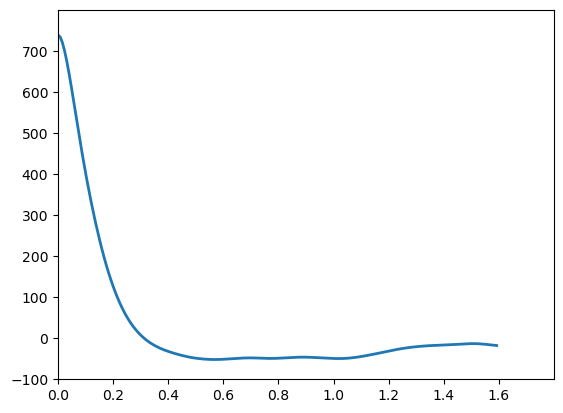

In [14]:
# plot
fig, ax = plt.subplots()
ax.plot(vdos.tau, np.sum(vdos.trCorr, axis = 1) / vdos.nRes, linewidth = 2.0)
ax.set(xlim=(0, 1.8), xticks=np.arange(0,1.8,0.2),
       ylim=(-100, 800), yticks=np.arange(-100,800,100))
plt.show()

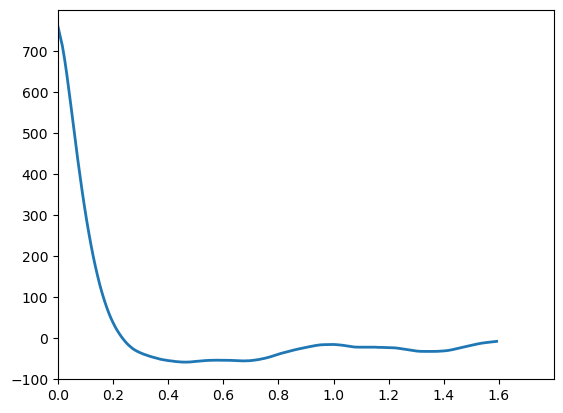

In [15]:
# plot
fig, ax = plt.subplots()
ax.plot(vdos.tau, np.sum(vdos.rotCorr, axis = 1) / vdos.nRes, linewidth = 2.0)
ax.set(xlim=(0, 1.8), xticks=np.arange(0,1.8,0.2),
       ylim=(-100, 800), yticks=np.arange(-100,800,100))
plt.show()

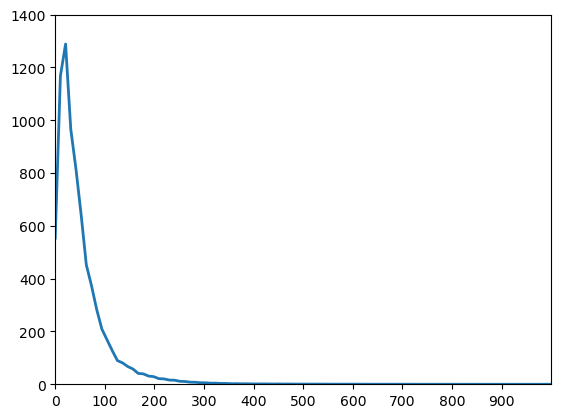

In [16]:
# plot
fig, ax = plt.subplots()
ax.plot(vdos.wavenumber, np.sum(vdos.trVDoS, axis = 1) / vdos.nRes, linewidth = 2.0)
ax.set(xlim=(0, 1000), xticks=np.arange(0,1000,100),
       ylim=(0, 1400.0), yticks=np.arange(0,1500,200))
plt.show()

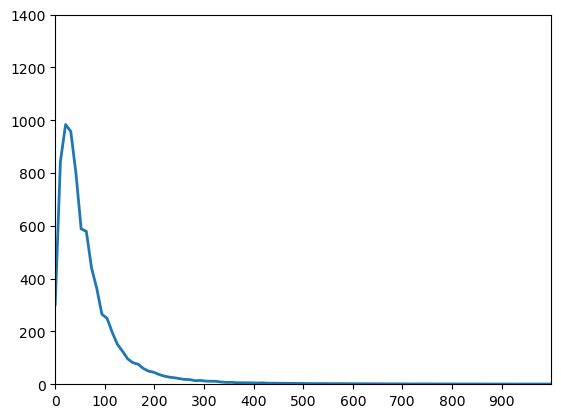

In [17]:
# plot
fig, ax = plt.subplots()
ax.plot(vdos.wavenumber, np.sum(vdos.rotVDoS, axis = 1) / vdos.nRes, linewidth = 2.0)
ax.set(xlim=(0, 1000), xticks=np.arange(0,1000,100),
       ylim=(0, 1400.0), yticks=np.arange(0,1500,200))
plt.show()